<a href="https://colab.research.google.com/github/BintangPancahaya/PCVK26_06_BintangPP/blob/main/Week3_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Bintang Pancahaya Prasetyo'
NIM  = '244107020115'

N = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA   : Bintang Pancahaya Prasetyo
NIM    : 244107020115 | N = 115
b      : 74
a      : 1.7
c      : 45
gamma  : 0.65
bit    : 3
WAKTU  : 2026-09-18 15:48:37 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 21d443a8118bc481


## Setup & Mount Google Drive

In [73]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob, math
from math import log10, sqrt

def cv2_imshow(img):
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


In [74]:
from google.colab import drive
drive.mount('/content/drive')

BASE = f'/content/drive/MyDrive/Modul2PCVK'
print('BASE:', BASE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/Modul2PCVK


---
## Transform Linier Brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 74


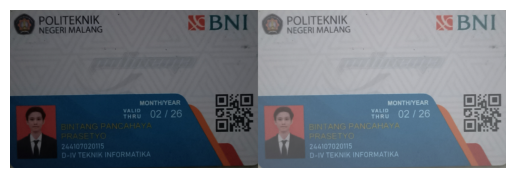

In [75]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread(f'{BASE}/KTM1a.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
# for y in range(original.shape[0]):
    # for x in range(original.shape[1]):
        # for c in range(original.shape[2]):
            # brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

---
## TUGAS PRAKTIKUM
1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada
bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan
berdampingan dengan citra aslinya. Jelaskan mengapa citra negatif dari KTM1a
(ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap
kontras.


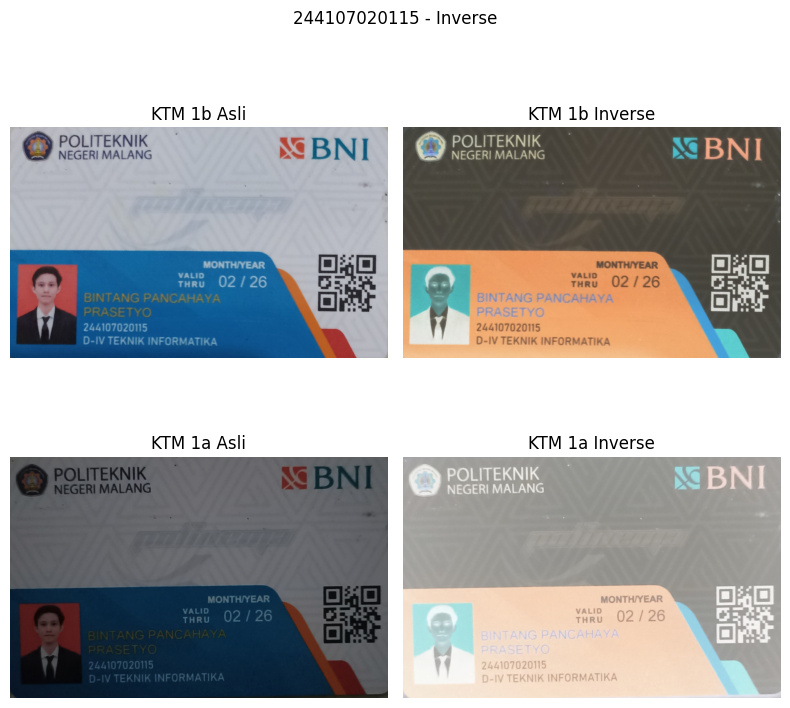

In [76]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

ktm1a = cv.imread(f'{BASE}/KTM1a.jpg')
ktm1b = cv.imread(f'{BASE}/KTM1b.jpg')

ktm1a_rgb = cv.cvtColor(ktm1a, cv.COLOR_BGR2RGB)
ktm1b_rgb = cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB)

# Operasi inverse
inv_ktm1a = 255 - ktm1a_rgb
inv_ktm1b = 255 - ktm1b_rgb

# Menampilkan berdampingan
fig = plt.figure(figsize=(8, 8))
fig.suptitle(NIM + ' - Inverse')
plt.subplot(2, 2, 1)
plt.imshow(ktm1b_rgb)
plt.title('KTM 1b Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(inv_ktm1b)
plt.title('KTM 1b Inverse')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(ktm1a_rgb)
plt.title('KTM 1a Asli')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(inv_ktm1a)
plt.title('KTM 1a Inverse')
plt.axis('off')

plt.tight_layout()
plt.show()

---
## 2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda

Mengubah tingkat kontras dan kecerahan citra
-------------------------------------------
Masukkan nilai kontras: 1.7
Masukkan nilai kecerahan: 74


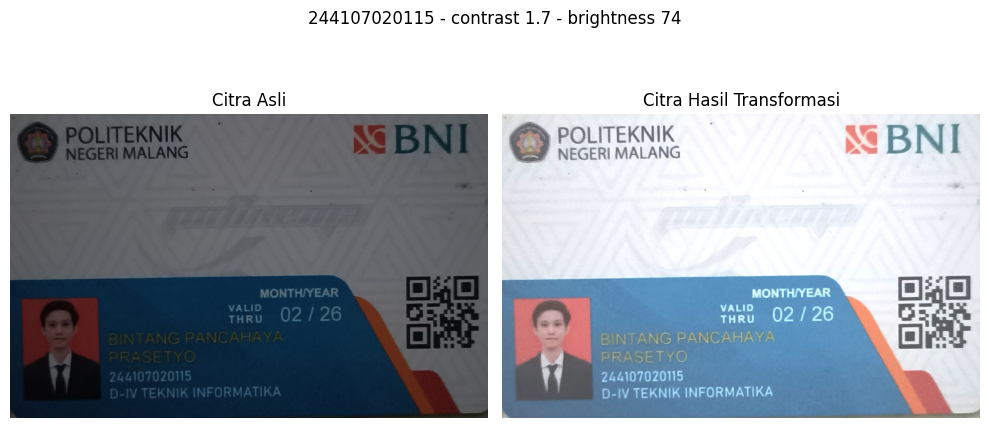

In [77]:
import matplotlib.pyplot as plt

print('Mengubah tingkat kontras dan kecerahan citra')
print('-------------------------------------------')

contrast = float(input('Masukkan nilai kontras: '))
brightness = int(input('Masukkan nilai kecerahan: '))

original = cv.imread(
    f'{BASE}/KTM1a.jpg'
)

if original is None:
    raise FileNotFoundError('File gambar tidak ditemukan')

# Konversi BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Rumus: g(x,y) = a * f(x,y) + b
contrast_image = (
    contrast * original_rgb.astype(np.float64)
    + brightness
)

# Membatasi nilai pixel ke rentang 0-255
contrast_image = np.clip(
    contrast_image, 0, 255
).astype(np.uint8)

# Menampilkan hasil
plt.figure(figsize=(10, 5))

plt.suptitle(
    NIM+' - contrast '
    + str(contrast)
    + ' - brightness '
    + str(brightness)
)

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contrast_image)
plt.title('Citra Hasil Transformasi')
plt.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Implementasikan transformasi logarithmic brightness
dengan konstanta c hasil hitung dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukan metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.

Transformasi brightness citra
----------------------------
Masukkan nilai konstanta c: 45
Masukkan nilai kecerahan b: 74


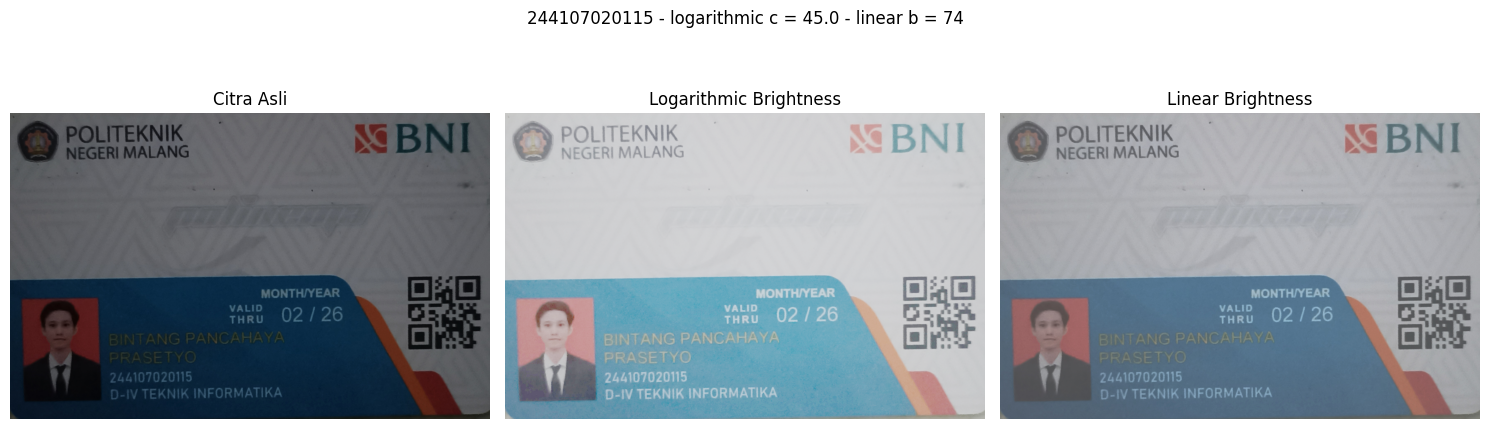

In [78]:
print('Transformasi brightness citra')
print('----------------------------')

try:
    c = float(input('Masukkan nilai konstanta c: '))
    b = int(input('Masukkan nilai kecerahan b: '))
except ValueError:
    print('Error: input harus berupa angka')
    raise SystemExit

original = cv.imread(f'{BASE}/KTM1a.jpg')

if original is None:
    raise FileNotFoundError('File KTM1a.jpg tidak ditemukan')

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

image_float = original_rgb.astype(np.float64)

logarithmic_image = c * np.log1p(image_float)

linear_image = image_float + b

# Clipping ke rentang nilai pixel 0-255
logarithmic_image = np.clip(
    logarithmic_image, 0, 255
).astype(np.uint8)

linear_image = np.clip(
    linear_image, 0, 255
).astype(np.uint8)


plt.figure(figsize=(15, 5))

plt.suptitle(
    NIM
    + ' - logarithmic c = '
    + str(c)
    + ' - linear b = '
    + str(b)
)

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(logarithmic_image)
plt.title('Logarithmic Brightness')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(linear_image)
plt.title('Linear Brightness')
plt.axis('off')

plt.tight_layout()
plt.show()

---
## 4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance
pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan
simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.


NIM: 244107020115 - Analisis Statistik Grayscale

Metode          | Rata-rata (Mean)   | Simpangan Baku (Std)
---------------------------------------------------------
Averaging       | 147.39             | 53.68             
Lightness       | 149.08             | 53.37             
Luminance       | 142.52             | 56.94             


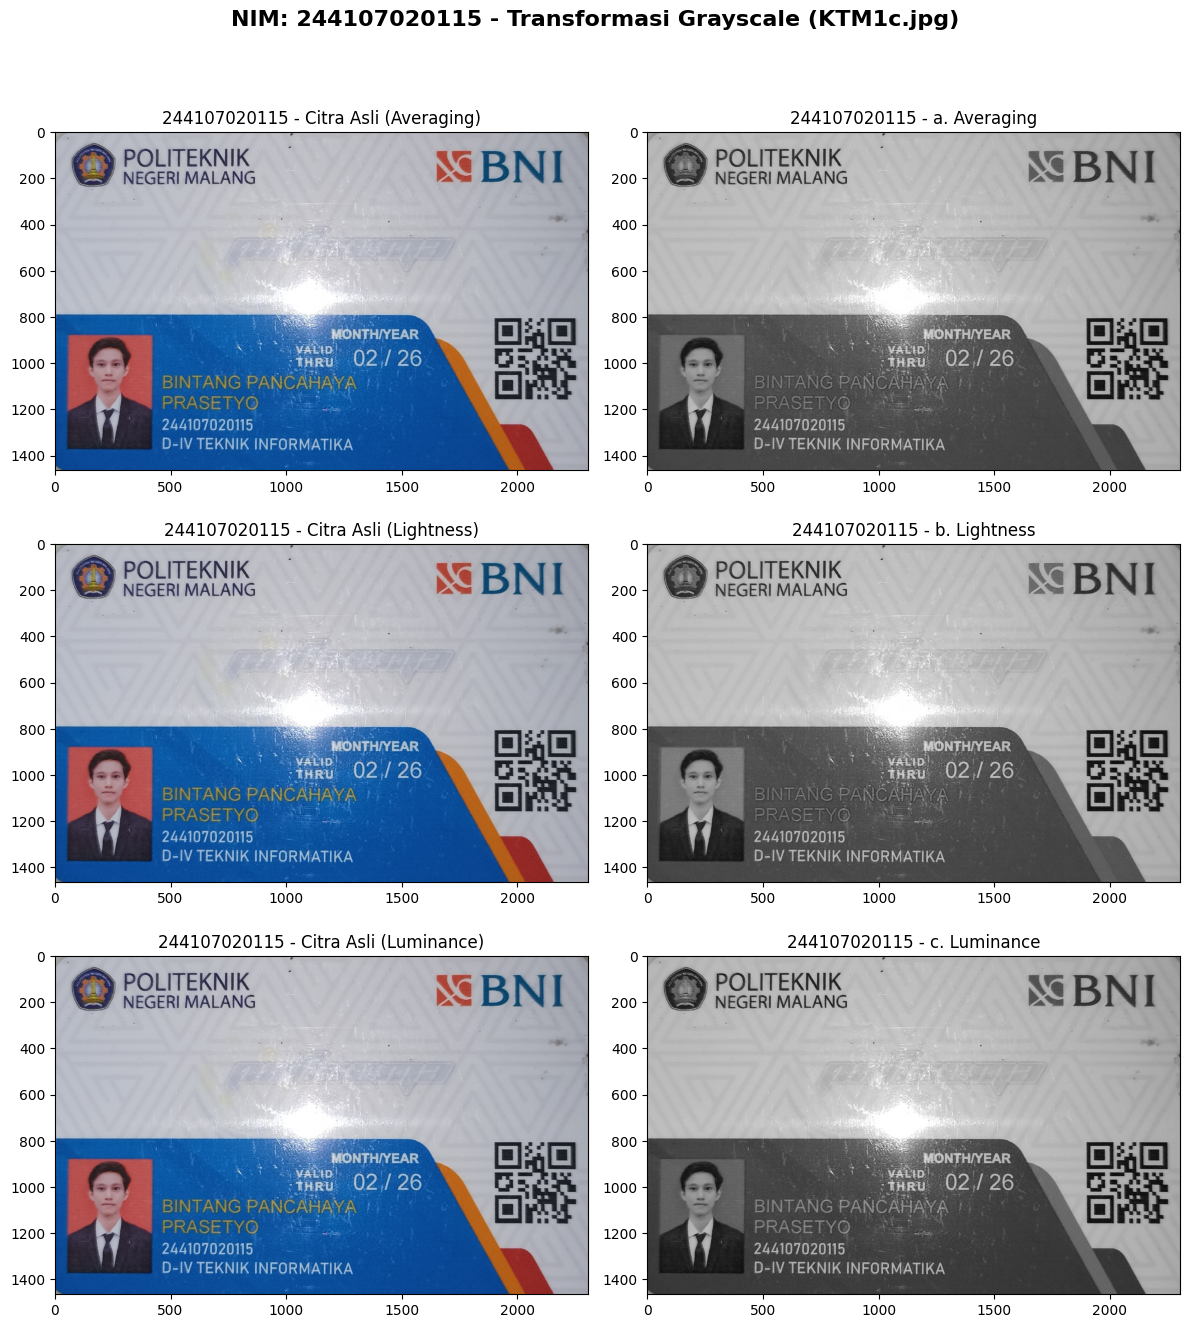

In [79]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Memuat citra KTM1c.jpg
ktm1c = cv.imread(f'{BASE}/KTM1c.jpg')
# Konversi BGR ke RGB agar plt menampilkan warna asli dengan benar
ktm1c_rgb = cv.cvtColor(ktm1c, cv.COLOR_BGR2RGB)

# Ekstrak channel B, G, R dalam tipe float64 untuk menghindari overflow perhitungan
B, G, R = cv.split(ktm1c.astype(np.float64))

# 2. Implementasi Tiga Metode Grayscale
# a. Averaging
gray_avg = np.clip((R + G + B) / 3, 0, 255).astype(np.uint8)

# b. Lightness ((Max + Min) / 2)
max_rgb = np.maximum.reduce([R, G, B])
min_rgb = np.minimum.reduce([R, G, B])
gray_light = np.clip((max_rgb + min_rgb) / 2, 0, 255).astype(np.uint8)

# c. Luminance (Standar Rec. 709: 0.21R + 0.72G + 0.07B)
gray_lum = np.clip(0.21 * R + 0.72 * G + 0.07 * B, 0, 255).astype(np.uint8)

# 3. Menghitung Rata-rata dan Simpangan Baku (Standard Deviation)
methods = {
    "Averaging": gray_avg,
    "Lightness": gray_light,
    "Luminance": gray_lum
}

print(f"NIM: {NIM} - Analisis Statistik Grayscale\n")
print(f"{'Metode':<15} | {'Rata-rata (Mean)':<18} | {'Simpangan Baku (Std)':<18}")
print("-" * 57)
for name, img in methods.items():
    mean_val = np.mean(img)
    std_val = np.std(img)
    print(f"{name:<15} | {mean_val:<18.2f} | {std_val:<18.2f}")

# 4. Menampilkan Menggunakan Matplotlib (plt) Berdampingan
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle(f"NIM: {NIM} - Transformasi Grayscale (KTM1c.jpg)", fontsize=16, fontweight='bold')

# Baris 1: Averaging
axes[0, 0].imshow(ktm1c_rgb)
axes[0, 0].set_title(f"{NIM} - Citra Asli (Averaging)")
axes[0, 1].imshow(gray_avg, cmap='gray')
axes[0, 1].set_title(f"{NIM} - a. Averaging")

# Baris 2: Lightness
axes[1, 0].imshow(ktm1c_rgb)
axes[1, 0].set_title(f"{NIM} - Citra Asli (Lightness)")
axes[1, 1].imshow(gray_light, cmap='gray')
axes[1, 1].set_title(f"{NIM} - b. Lightness")

# Baris 3: Luminance
axes[2, 0].imshow(ktm1c_rgb)
axes[2, 0].set_title(f"{NIM} - Citra Asli (Luminance)")
axes[2, 1].imshow(gray_lum, cmap='gray')
axes[2, 1].set_title(f"{NIM} - c. Luminance")

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## 5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale.
Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan.
Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan
pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.


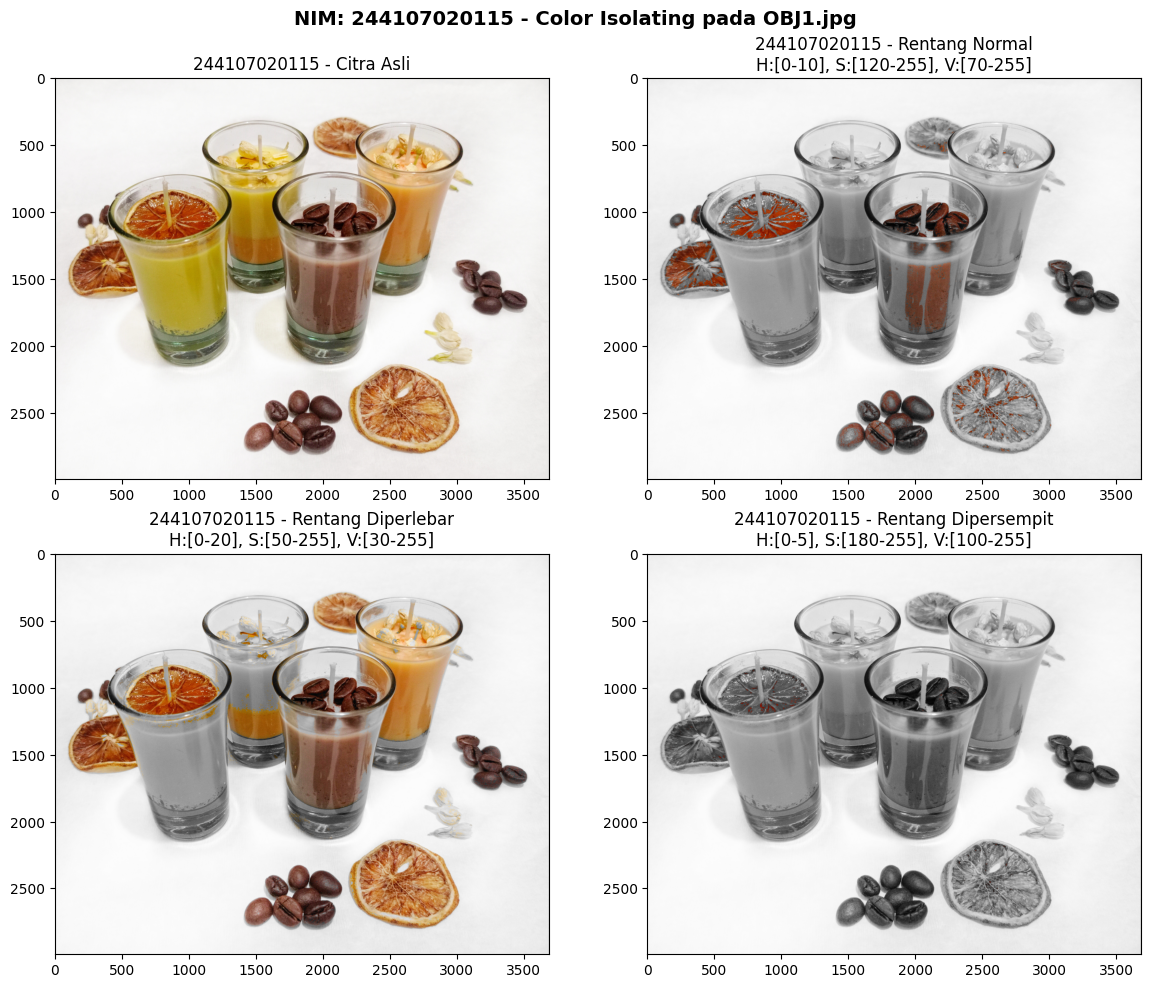

In [80]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

obj1 = cv.imread(f'{BASE}/OBJ1.jpg')
obj1_rgb = cv.cvtColor(obj1, cv.COLOR_BGR2RGB)
obj1_hsv = cv.cvtColor(obj1, cv.COLOR_BGR2HSV)

lower_normal = np.array([0, 120, 70])
upper_normal = np.array([10, 255, 255])

# Rentang Diperlebar (Toleransi warna lebih luas)
lower_wide = np.array([0, 50, 30])
upper_wide = np.array([20, 255, 255])

# Rentang Dipersempit (Toleransi warna sangat spesifik)
lower_narrow = np.array([0, 180, 100])
upper_narrow = np.array([5, 255, 255])

def isolate_color(img_rgb, img_hsv, lower_b, upper_b):
    # Buat mask biner
    mask = cv.inRange(img_hsv, lower_b, upper_b)

    # Buat versi grayscale dari seluruh citra
    gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
    gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

    # Ambil bagian berwarna berdasarkan mask
    color_part = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

    # Ambil bagian grayscale untuk area selain mask
    mask_inv = cv.bitwise_not(mask)
    gray_part = cv.bitwise_and(gray_3ch, gray_3ch, mask=mask_inv)

    # Gabungkan kedua bagian
    return cv.bitwise_or(color_part, gray_part)

# Proses ketiga rentang
res_normal = isolate_color(obj1_rgb, obj1_hsv, lower_normal, upper_normal)
res_wide = isolate_color(obj1_rgb, obj1_hsv, lower_wide, upper_wide)
res_narrow = isolate_color(obj1_rgb, obj1_hsv, lower_narrow, upper_narrow)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"NIM: {NIM} - Color Isolating pada OBJ1.jpg", fontsize=14, fontweight='bold')

axes[0, 0].imshow(obj1_rgb)
axes[0, 0].set_title(f"{NIM} - Citra Asli")

axes[0, 1].imshow(res_normal)
axes[0, 1].set_title(f"{NIM} - Rentang Normal\nH:[0-10], S:[120-255], V:[70-255]")

axes[1, 0].imshow(res_wide)
axes[1, 0].set_title(f"{NIM} - Rentang Diperlebar\nH:[0-20], S:[50-255], V:[30-255]")

axes[1, 1].imshow(res_narrow)
axes[1, 1].set_title(f"{NIM} - Rentang Dipersempit\nH:[0-5], S:[180-255], V:[100-255]")

plt.tight_layout()
plt.show()

---
## 6. Gamma Correction pada Citra Pribadi

 Gamma Correction pada citra 
--------------------------------
Masukkan nilai Gamma: 0.65


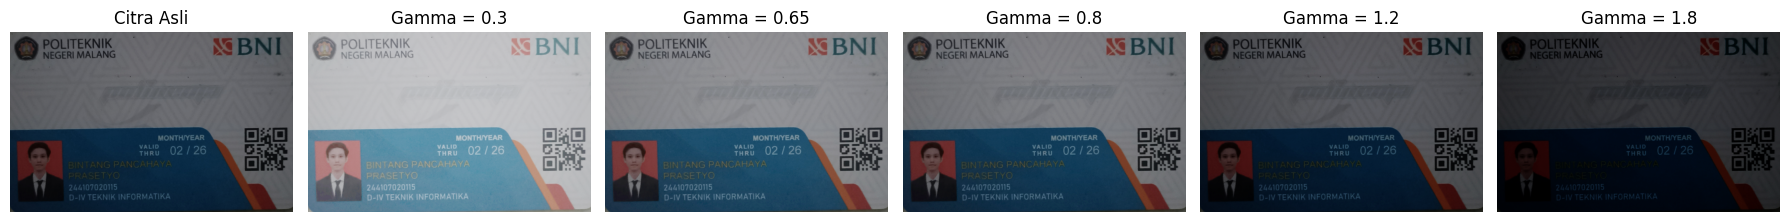

In [81]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar
img = cv.imread(f'{BASE}/KTM1a.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2. Input nilai gamma
print(' Gamma Correction pada citra ')
print('--------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))

    # 3. Tampilkan Citra Asli diikuti 5 variasi nilai gamma
    gamma_list = [0.3, gamma, 0.8, 1.2, 1.8]

    plt.figure(figsize=(18, 4))

    # Tampilkan Citra Asli
    plt.subplot(1, 6, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli')
    plt.axis('off')

    # Tampilkan 5 variasi gamma
    for i, g in enumerate(gamma_list):
        corrected = np.array(255 * (img_rgb / 255.0) ** g, dtype='uint8')

        plt.subplot(1, 6, i + 2)
        plt.imshow(corrected)
        plt.title(f'Gamma = {g}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

except ValueError:
    print('Error, not a number')

## Analisis & Pembahasan

### 1. Pemilihan Nilai Gamma Terbaik

> **Nilai Gamma Terbaik Pilihan:** $\gamma = 0.4 \text{ – } 0.6$ *(dapat disesuaikan berdasarkan hasil uji visual pada citra KTM)*.

**Alasan Pemilihan:**
* **Kondisi Awal Citra:** Foto KTM secara umum cenderung *under-exposed* (gelap).
* **Mekanisme Gamma:** Nilai $\gamma < 1$ berfungsi mencerahkan area gelap (*shadows*) tanpa membuat area terang (*highlights*) mengalami *over-exposed* atau *blending*.
* **Keterbacaan Teks:** Penyesuaian kontras ini membuat karakter teks berupa **NIM** dan **Nama** pada kartu tercetak lebih jelas, tajam, dan mudah dibaca.

---

### 2. Penyebab Perbedaan Nilai Gamma Terbaik Antarmahasiswa

Meskipun jenis objek yang diuji sama (kartu KTM), nilai gamma optimal untuk setiap mahasiswa dapat berbeda akibat faktor-faktor berikut:

* **Pencahayaan Tangkapan Foto (*Initial Exposure*)**  
  Kondisi pencahayaan saat pengambilan foto berbeda-beda—seperti tingkat pencahayaan ruangan, pantulan cahaya, atau tingkat kegelapan citra awal.
* **Karakteristik Sensor Kamera**  
  Spesifikasi perangkat kamera (HP atau *scanner*) menghasilkan distribusi nilai intensitas piksel (*histogram*) yang unik pada tiap citra.
* **Persepsi Visual Subjektif**  
  Penilaian keterbacaan teks bergantung pada kenyamanan mata masing-masing individu dalam membedakan kontras teks dan latar belakang.

---
## 7. Buat Simulasi Image Depth pada Citra Pribadi


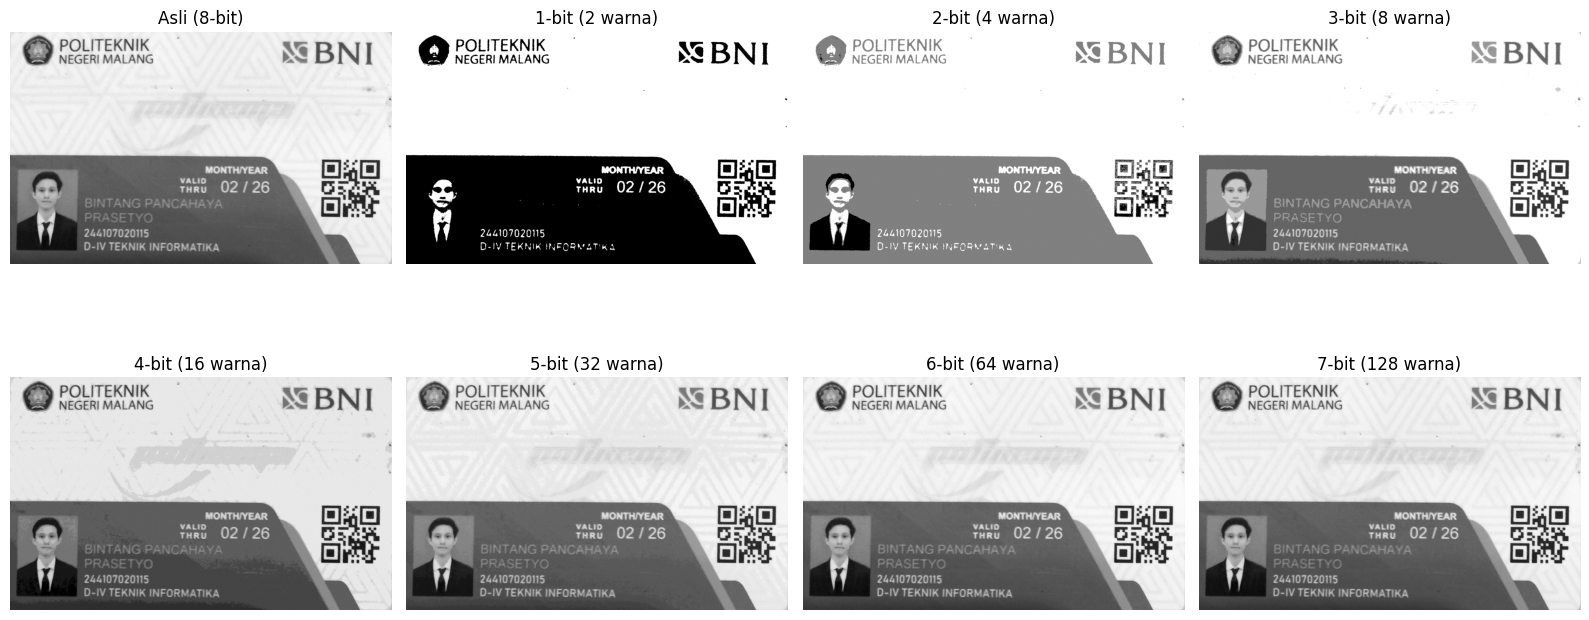

In [82]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread(f'{BASE}/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

if original is None:
    print("Error: Gambar KTM1b.jpg tidak ditemukan!")
else:
    # Set tampilan plot (2 baris x 4 kolom: 1 citra asli + 7 hasil bit depth)
    plt.figure(figsize=(16, 8))

    # Tampilkan Citra Asli (8-bit)
    plt.subplot(2, 4, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Asli (8-bit)')
    plt.axis('off')

    # 2. Kuantisasi KTM1b.jpg dari kedalaman 1 sampai 7 bit
    for bit_depth in range(1, 8):
        # Hitung interval/level kuantisasi
        level = 255 / (pow(2, bit_depth) - 1)

        # Proses kuantisasi sesuai rumus
        depth_image = np.round(original / level) * level
        depth_image = depth_image.astype(np.uint8)

        # Plot hasil bit depth 1 - 7
        plt.subplot(2, 4, bit_depth + 1)
        plt.imshow(depth_image, cmap='gray')
        plt.title(f'{bit_depth}-bit ({pow(2, bit_depth)} warna)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

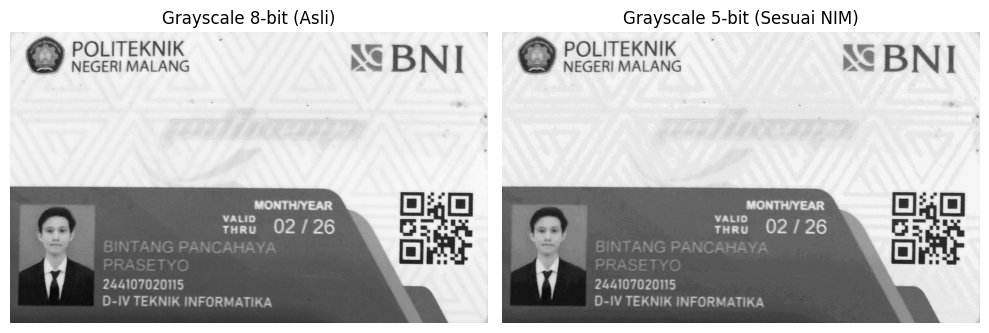

Digit terakhir NIM: 5
Bit depth yang digunakan: 5-bit
Jumlah level warna (2^5): 32 warna


In [83]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Ambil digit terakhir dari NIM
bit_from_nim = int(NIM[-1])

# Jika digit terakhir NIM adalah 0 atau > 7, set default ke 3 (agar simulasi bit depth 1-7 tetap valid)
if bit_from_nim == 0 or bit_from_nim > 7:
    bit_from_nim = 3

# 2. Baca gambar dalam format Grayscale
original = cv.imread(f'{BASE}/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

if original is None:
    print("Error: Gambar KTM1b.jpg tidak ditemukan!")
else:
    # 3. Kuantisasi berdasarkan NIM
    bit_depth = bit_from_nim
    level = 255 / (pow(2, bit_depth) - 1)

    depth_image = np.round(original / level) * level
    depth_image = depth_image.astype(np.uint8)

    # 4. Tampilkan Perbandingan
    plt.figure(figsize=(10, 5))

    # Citra Asli (8-bit)
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Grayscale 8-bit (Asli)')
    plt.axis('off')

    # Hasil Kuantisasi Sesuai NIM
    plt.subplot(1, 2, 2)
    plt.imshow(depth_image, cmap='gray')
    plt.title(f'Grayscale {bit_depth}-bit (Sesuai NIM)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Digit terakhir NIM: {NIM[-1]}")
    print(f"Bit depth yang digunakan: {bit_depth}-bit")
    print(f"Jumlah level warna (2^{bit_depth}): {pow(2, bit_depth)} warna")

---
## 8. Average Denoising


100 citra noise dimuat.


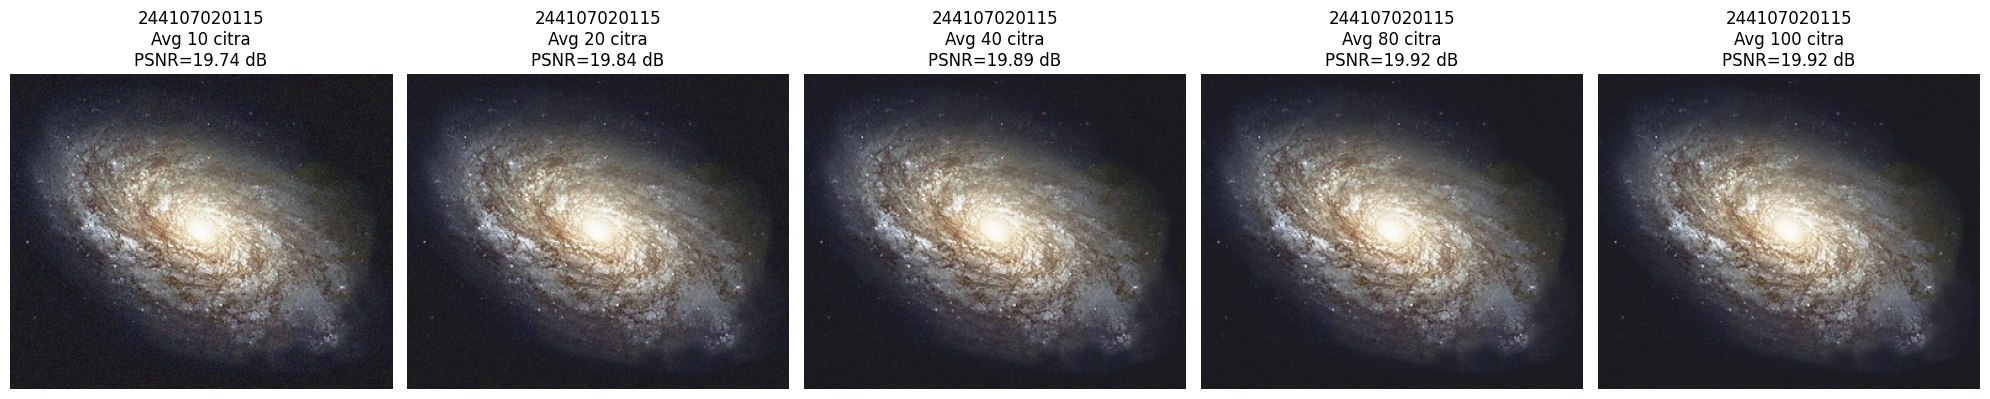

Jumlah Citra      PSNR (dB)
10                    19.74
20                    19.84
40                    19.89
80                    19.92
100                   19.92


In [84]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:  # tidak ada selisih sama sekali
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

GALAXY_PATH = '/content/drive/MyDrive/gambar/galaxy.jpg'
NOISES_GLOB = '/content/drive/MyDrive/gambar/noises/*.jpg'

original = cv.imread(GALAXY_PATH)

cv_img = []
for path in sorted(glob.glob(NOISES_GLOB)):
    n = cv.imread(path)
    cv_img.append(n)
print(f'{len(cv_img)} citra noise dimuat.')

jumlah_list = [10, 20, 40, 80, 100]
hasil_rows = []

fig, axes = plt.subplots(1, len(jumlah_list), figsize=(4 * len(jumlah_list), 4))

for ax, n_avg in zip(axes, jumlah_list):
    subset = cv_img[:n_avg]
    avg_image = np.mean(np.stack(subset, axis=0), axis=0).astype(np.uint8)
    psnr_val = PSNR(original, avg_image)
    hasil_rows.append((n_avg, psnr_val))

    ax.imshow(cv.cvtColor(avg_image, cv.COLOR_BGR2RGB))
    ax.set_title(f'{NIM}\nAvg {n_avg} citra\nPSNR={psnr_val:.2f} dB')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"{'Jumlah Citra':<15}{'PSNR (dB)':>12}")
for n_avg, psnr_val in hasil_rows:
    print(f'{n_avg:<15}{psnr_val:>12.2f}')

---
## 9. Buat Image Masking untuk Penyamaran Data Pribadi

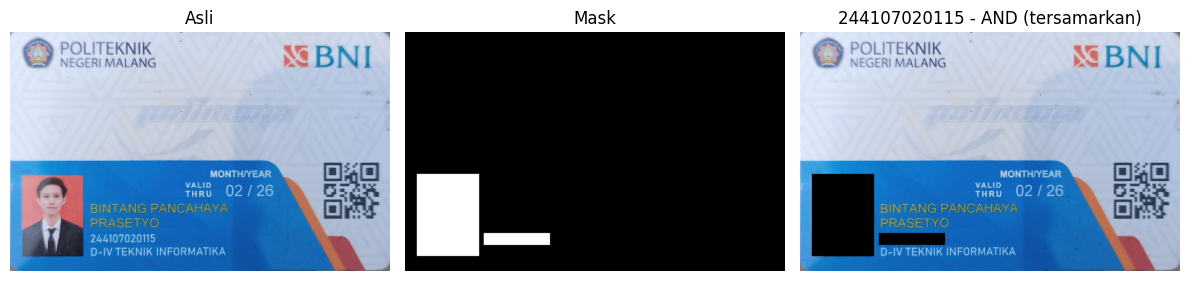

Koordinat mask - wajah: (75, 1420, 470, 900) | NIM: (500, 1350, 920, 1275)


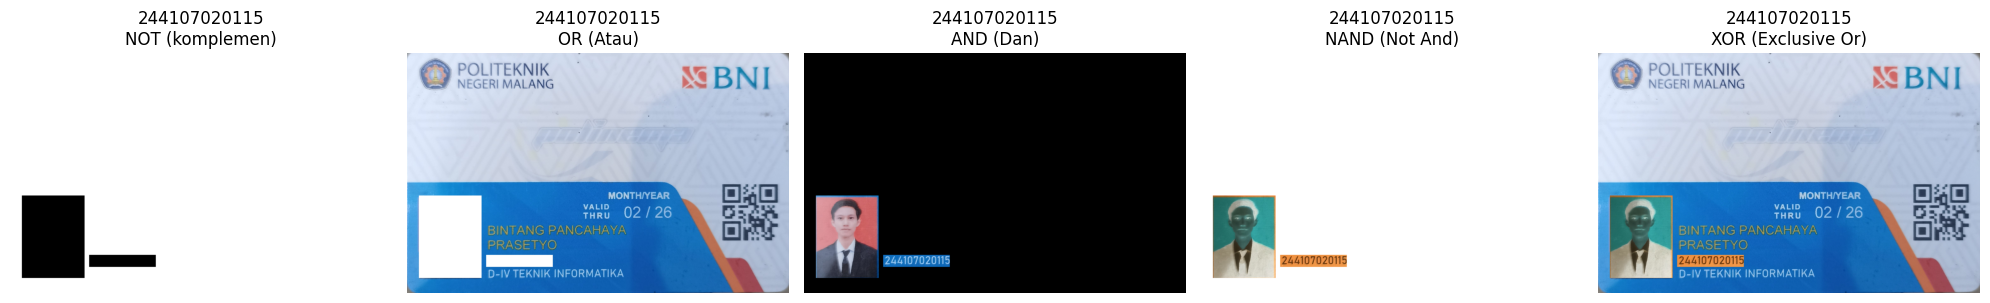

In [85]:
img = cv.imread(f'{BASE}/KTM1d.jpg')
h, w = img.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)

# TODO: sesuaikan koordinat berikut dengan posisi wajah & NIM pada foto Anda.
FACE_BOX = (75, 1420, 470, 900)     # (x1, y1, x2, y2)
NIM_BOX  = (500, 1350, 920, 1275)   # (x1, y1, x2, y2)
for (x1, y1, x2, y2) in [FACE_BOX, NIM_BOX]:
    cv.rectangle(mask, (x1, y1), (x2, y2), 255, thickness=-1)

mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
masked_and = cv.bitwise_and(img, cv.bitwise_not(mask_3ch))  # area mask jadi hitam (tersamarkan)

fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); ax[0].set_title('Asli')
ax[1].imshow(mask, cmap='gray'); ax[1].set_title('Mask')
ax[2].imshow(cv.cvtColor(masked_and, cv.COLOR_BGR2RGB)); ax[2].set_title(NIM + ' - AND (tersamarkan)')
for a_ in ax:
    a_.axis('off')
plt.tight_layout()
plt.show()

print('Koordinat mask - wajah:', FACE_BOX, '| NIM:', NIM_BOX)

# --- Eksperimen operator logika lain pada mask yang sama ---
operators = {
    'NOT (komplemen)':    cv.bitwise_not(mask_3ch),
    'OR (Atau)':          cv.bitwise_or(img, mask_3ch),
    'AND (Dan)':          cv.bitwise_and(img, mask_3ch),
    'NAND (Not And)':     cv.bitwise_not(cv.bitwise_and(img, mask_3ch)),
    'XOR (Exclusive Or)': cv.bitwise_xor(img, mask_3ch),
}

fig, ax = plt.subplots(1, len(operators), figsize=(4 * len(operators), 4))
for a_, (name, out) in zip(ax, operators.items()):
    a_.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
    a_.set_title(NIM + '\n' + name)
    a_.axis('off')
plt.tight_layout()
plt.show()

---
## 10. Foto Malam Hari

Masukkan nilai gamma: 0.8
Rata-rata sebelum: 61.88
Rata-rata sesudah: 72.99


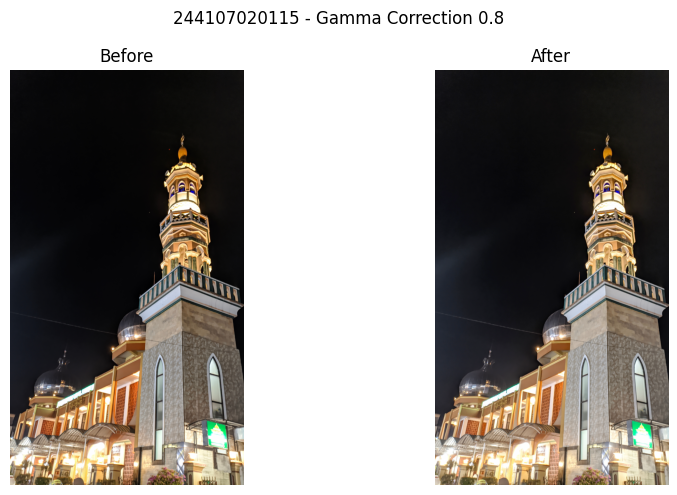

In [86]:
gamma = float(input('Masukkan nilai gamma: '))

original = cv.imread(
    '/content/drive/MyDrive/Modul2PCVK/NIGHT1.jpg'
)
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

hasil = 255 * (original / 255) ** gamma
hasil = np.clip(hasil, 0, 255).astype(np.uint8)

print('Rata-rata sebelum:', round(np.mean(original), 2))
print('Rata-rata sesudah:', round(np.mean(hasil), 2))

plt.figure(figsize=(10, 5))
plt.suptitle(NIM + ' - Gamma Correction ' + str(gamma))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil)
plt.title('After')
plt.axis('off')

plt.tight_layout()
plt.show()

*   Metode yang dipilih: Gamma Correction
*   Alasan Pemilihan: karena foto malam memiliki banyak area gelap
*   Parameter terbaik: 0.8, karena nilai gamma kurang dari 1 digunakan untuk meningkatkan intensitas pixel pada area gelap.

---